Đọc dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import load_data

df = load_data()
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Kiểm tra chất lượng dữ liệu

In [2]:
print("--- Kích thước dữ liệu (Shape) ---")
print(df.shape)

print("\n--- Thông tin chi tiết (Info) ---")
df.info()

print("\n--- Thống kê mô tả (Describe) ---")
display(df.describe())

print("\n--- Kiểm tra giá trị khuyết thiếu (Null) ---")
print(df.isnull().sum())

print("\n--- Kiểm tra dữ liệu trùng lặp ---")
print("Số dòng trùng lặp:", df.duplicated().sum())

print("\n--- Tỷ lệ phân phối nhãn Stroke (%) ---")
print(df["stroke"].value_counts(normalize=True) * 100)

--- Kích thước dữ liệu (Shape) ---
(5110, 11)

--- Thông tin chi tiết (Info) ---
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 594.7 KB

--- Thống kê mô tả (Describe) ---


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



--- Kiểm tra giá trị khuyết thiếu (Null) ---
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

--- Kiểm tra dữ liệu trùng lặp ---
Số dòng trùng lặp: 0

--- Tỷ lệ phân phối nhãn Stroke (%) ---
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


## Nhận xét — Chất lượng dữ liệu

Bộ dữ liệu có 5.110 dòng, 11 cột, không có dòng trùng lặp. Duy nhất cột `bmi` bị thiếu
201 giá trị (~3.9%). Nhãn mục tiêu `stroke` mất cân bằng nghiêm trọng: 95.13% không
đột quỵ, chỉ 4.87% có đột quỵ (249/5110 ca) — đây là đặc điểm quan trọng nhất chi phối
toàn bộ lựa chọn kỹ thuật ở các bước xử lý và đánh giá mô hình sau này.

5 nhóm biểu đồ

C:\Users\DELL\AppData\Local\Temp\ipykernel_29868\1610241054.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="stroke", palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_29868\1610241054.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="stroke", y="age", palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_29868\1610241054.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="stroke", y="bmi", palette="Set2")
C:\Users\DELL\AppData\Local\Temp\ipykernel_29868\1610241054.py:20: FutureWarni

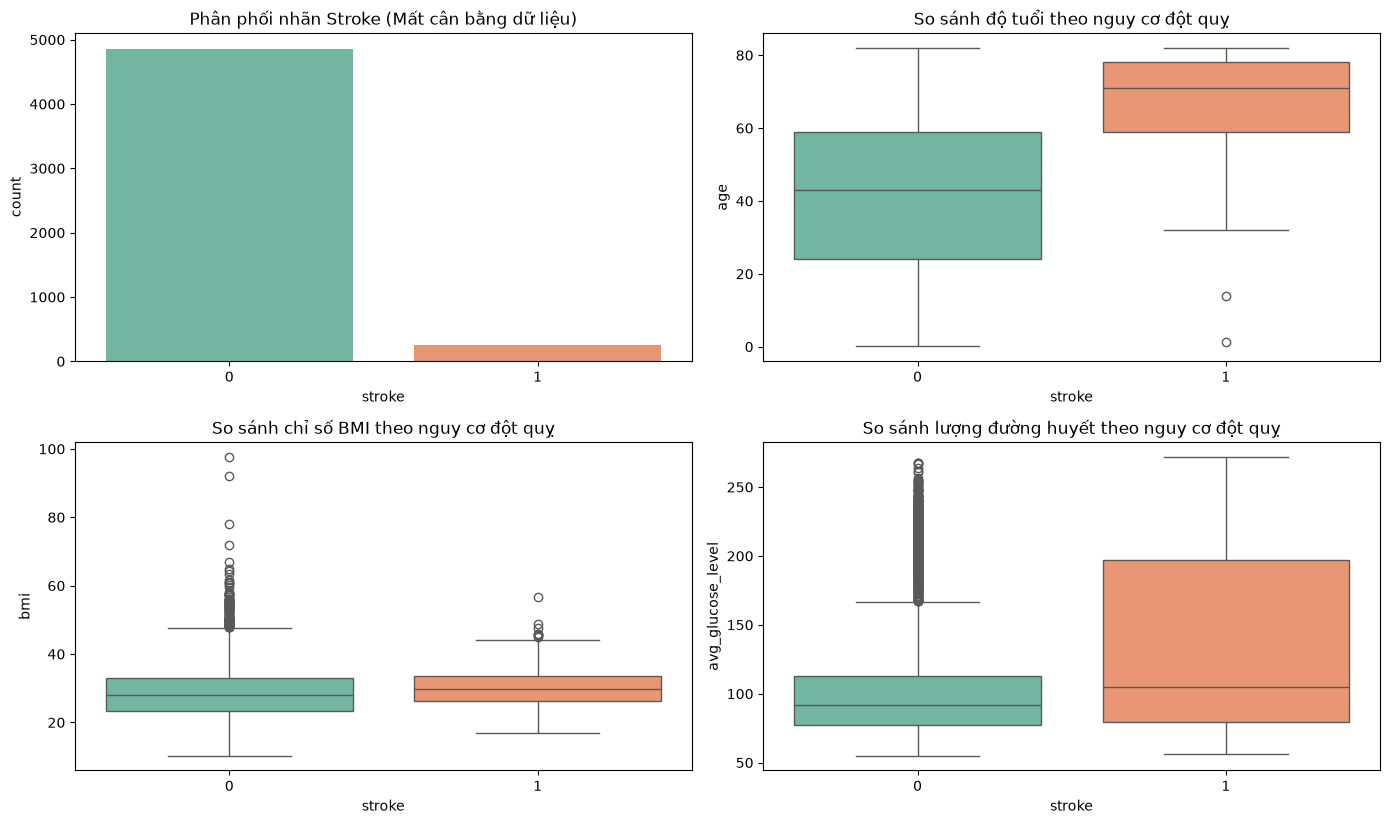

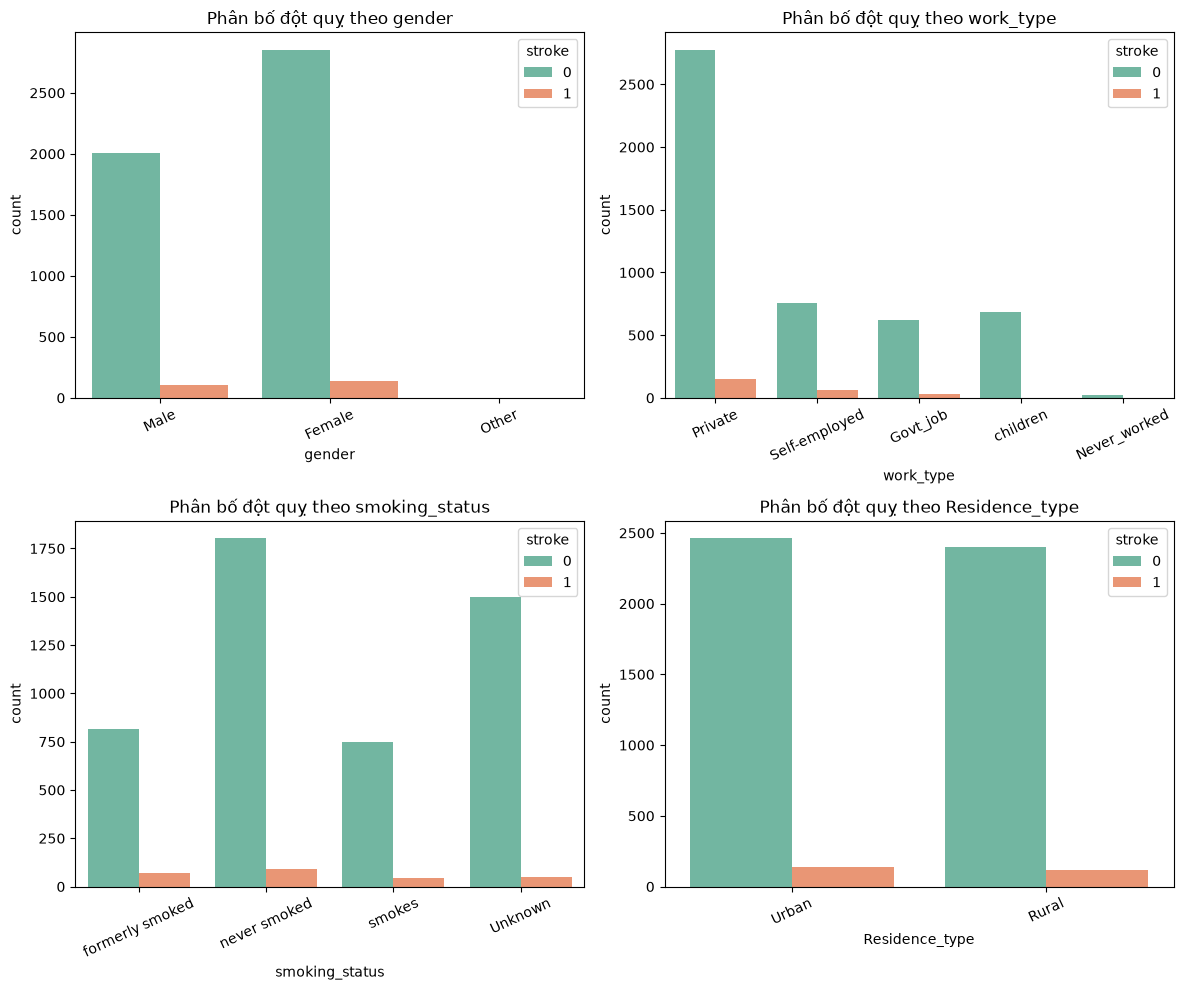

In [3]:
plt.figure(figsize=(14, 12))

# 1. Phân phối biến mục tiêu Stroke
plt.subplot(3, 2, 1)
sns.countplot(data=df, x="stroke", palette="Set2")
plt.title("Phân phối nhãn Stroke (Mất cân bằng dữ liệu)")

# 2. Boxplot: Tuổi và Đột quỵ
plt.subplot(3, 2, 2)
sns.boxplot(data=df, x="stroke", y="age", palette="Set2")
plt.title("So sánh độ tuổi theo nguy cơ đột quỵ")

# 3. Boxplot: BMI và Đột quỵ
plt.subplot(3, 2, 3)
sns.boxplot(data=df, x="stroke", y="bmi", palette="Set2")
plt.title("So sánh chỉ số BMI theo nguy cơ đột quỵ")

# 4. Boxplot: Đường huyết trung bình và Đột quỵ
plt.subplot(3, 2, 4)
sns.boxplot(data=df, x="stroke", y="avg_glucose_level", palette="Set2")
plt.title("So sánh lượng đường huyết theo nguy cơ đột quỵ")

plt.tight_layout()
plt.show()

# 5. Biểu đồ nhóm các biến phân loại chính
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cat_cols = ["gender", "work_type", "smoking_status", "Residence_type"]
for col, ax in zip(cat_cols, axes.ravel()):
    sns.countplot(data=df, x=col, hue="stroke", ax=ax, palette="Set2")
    ax.set_title(f"Phân bố đột quỵ theo {col}")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Nhận xét — Trực quan hóa dữ liệu

- Phân phối `stroke` cho thấy rõ mất cân bằng lớp (biểu đồ cột chênh lệch rất lớn).
- Nhóm có đột quỵ có tuổi trung vị cao hơn rõ rệt (~70 so với ~42) trong bộ dữ liệu này.
  Đây là mô tả liên hệ quan sát được, không chứng minh quan hệ nhân quả.
- `avg_glucose_level` ở nhóm có đột quỵ có trung vị và độ phân tán cao hơn trong biểu đồ.
  Kết quả này mô tả dữ liệu, không xác định tình trạng tiểu đường của từng người.
- `bmi` giữa 2 nhóm khá tương đồng, không có khác biệt rõ rệt bằng mắt thường —
  khớp với hệ số tương quan rất thấp (0.04) tính được ở bước sau.
- Các biến phân loại (gender, work_type, smoking_status, Residence_type) không cho
  thấy khác biệt tỷ lệ đột quỵ rõ rệt giữa các nhóm con khi nhìn trực quan.

IQR + tương quan

Cột bmi: phát hiện 110 outliers (giữ nguyên không loại bỏ để bảo toàn dữ liệu y tế).
Cột avg_glucose_level: phát hiện 627 outliers (giữ nguyên không loại bỏ để bảo toàn dữ liệu y tế).


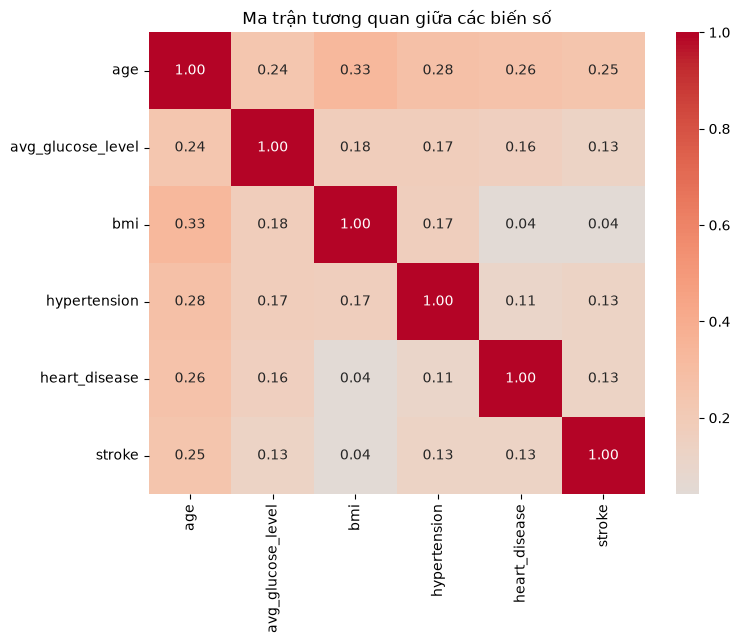

In [4]:
# Kiểm tra Outliers bằng IQR nhưng KHÔNG XÓA (đối với y tế)
for col in ["bmi", "avg_glucose_level"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outlier = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"Cột {col}: phát hiện {n_outlier} outliers (giữ nguyên không loại bỏ để bảo toàn dữ liệu y tế).")

# Tính toán ma trận tương quan các biến số
corr = df[["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến số")
plt.savefig("results/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Nhận xét — Outlier và tương quan

IQR phát hiện 110 điểm ngoài khoảng ở `bmi` và 627 điểm ở `avg_glucose_level`. Đây là
cờ thống kê theo quy tắc IQR, không tự xác định điểm nào là lỗi đo. Nhóm giữ nguyên
các giá trị trong phân tích hiện tại vì chưa có căn cứ xác minh chúng là lỗi; cần diễn
giải các điểm này thận trọng và không suy ra trạng thái bệnh từ một phép đo đơn lẻ.

Ma trận tương quan cho thấy `age` có tương quan mạnh nhất với `stroke` (0.25),
tiếp theo là `hypertension` và `heart_disease` (đều 0.13). Đáng chú ý, `bmi` có
tương quan rất yếu với `stroke` (0.04) dù thường được cho là yếu tố nguy cơ quan
trọng — có thể vì ảnh hưởng của BMI lên đột quỵ không tuyến tính hoặc cần kết hợp
với biến khác. Không phát hiện cặp biến số nào tương quan đủ mạnh (>0.5) để lo
ngại đa cộng tuyến nghiêm trọng.

In [5]:
# 1. Khảo sát độ tuổi theo từng nhóm công việc (work_type)
print("--- Thống kê độ tuổi theo nhóm công việc ---")
display(df.groupby("work_type")["age"].describe())

# 2. Kiểm tra tỷ lệ đột quỵ giữa nhóm có dữ liệu BMI bị thiếu (Null) và không thiếu
stroke_rate_missing = df.loc[df["bmi"].isnull(), "stroke"].mean()
stroke_rate_normal = df.loc[df["bmi"].notnull(), "stroke"].mean()

print(f"\nTỷ lệ đột quỵ ở nhóm thiếu BMI: {stroke_rate_missing:.4f}")
print(f"Tỷ lệ đột quỵ ở nhóm có đủ BMI: {stroke_rate_normal:.4f}")

--- Thống kê độ tuổi theo nhóm công việc ---


,count,mean,std,min,25%,50%,75%,max
work_type,,,,,,,,
Govt_job,657.0,50.879756,15.438879,14.00,40.00,51.0,62.0,82.0
Never_worked,22.0,16.181818,2.342899,13.00,14.25,16.0,17.0,23.0
Private,2925.0,45.503932,18.444200,8.00,30.00,45.0,59.0,82.0
Self-employed,819.0,60.201465,16.835961,7.00,49.00,63.0,75.0,82.0
children,687.0,6.841339,4.533364,0.08,2.00,6.0,11.0,16.0



Tỷ lệ đột quỵ ở nhóm thiếu BMI: 0.1990
Tỷ lệ đột quỵ ở nhóm có đủ BMI: 0.0426


## Nhận xét — Kiểm tra sâu bổ sung

`work_type='children'` có tuổi trung bình chỉ 6.84 (tối đa 16 tuổi) — xác nhận đây
gần như là biến mã hóa gián tiếp cho nhóm tuổi nhỏ. Mô hình có thể tận dụng đặc
điểm này như một cách nhận diện nhóm tuổi, đây là đặc tính hợp lệ của dữ liệu, không
phải rò rỉ nhãn, vì work_type được biết trước khi biết kết quả stroke.

Tỷ lệ đột quỵ quan sát được ở nhóm thiếu bmi là 19.90%, so với 4.26% ở nhóm có bmi.
Sự khác biệt này cho thấy trạng thái thiếu bmi có liên hệ với nhãn trong mẫu dữ liệu,
nhưng riêng quan sát này chưa đủ để kết luận cơ chế thiếu dữ liệu là MNAR. Pipeline
giữ cờ thiếu (`add_indicator=True`) để mô hình có thể đánh giá thông tin này trong
cross-validation, với imputation được fit riêng trong từng fold.